# Notebook 02 — Feature Engineering
## FORCE 2020 Well Log Lithofacies Dataset

**Goal:** Transform raw LAS log curves into a rich, model-ready feature set.

**From Notebook 01 we know:**
- Core curves available in all 118 wells: GR, RDEP, RMED, RHOB, NPHI, DTC, CALI, DRHO
- NPHI is 55% null overall (depth-limited coverage) — needs per-well imputation
- Shale dominates at 61.3% — severe class imbalance
- 2,337,639 total samples across 118 wells

**What we engineer:**
1. Per-well median imputation for missing curves
2. Petrophysical derived features (Vshale, apparent porosity, impedance)
3. Depth-context features (rolling statistics, depth-normalized values)
4. Spatial features (X, Y, Z positions)
5. Stratigraphic group encoding
6. Final feature matrix saved as parquet for Notebooks 03 and 04


In [1]:
import warnings; warnings.filterwarnings("ignore")
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lasio
from pathlib import Path
from tqdm import tqdm

from config import LAS_DIR, LITH_MAP, LITH_COLORS, CORE_CURVES, TARGET_COL, DEPTH_COL, PROC_DIR, FIGS

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"]   = "#f8f9fa"

print("Loading all wells (reusing load_las from Notebook 01)...")


Loading all wells (reusing load_las from Notebook 01)...


In [2]:
def load_las(path):
    try:
        las = lasio.read(path, ignore_header_errors=True)
        df  = las.df().reset_index()
        df.columns = [c.upper() for c in df.columns]
        if "DEPT" in df.columns and "DEPTH_MD" not in df.columns:
            df = df.rename(columns={"DEPT": "DEPTH_MD"})
        df["WELL"] = path.stem
        df = df.replace(-999.25, np.nan).replace(-9999.0, np.nan)
        if TARGET_COL in df.columns:
            df["LITHOFACIES"] = df[TARGET_COL].map(LITH_MAP)
        # Extract well location from median of X/Y/Z columns
        for col in ["X_LOC", "Y_LOC", "Z_LOC"]:
            if col in df.columns:
                df[col] = df[col].replace(0, np.nan)
        return df
    except Exception as e:
        print(f"  Warning: {path.name} — {e}")
        return None

las_files = sorted(LAS_DIR.glob("*.las"))
dfs = []
for f in tqdm(las_files, ncols=80):
    df = load_las(f)
    if df is not None:
        dfs.append(df)

combined = pd.concat(dfs, ignore_index=True)
print(f"Combined: {combined.shape}  |  Wells: {combined['WELL'].nunique()}")


100%|█████████████████████████████████████████| 118/118 [00:51<00:00,  2.28it/s]


Combined: (2337639, 29)  |  Wells: 118


## 1. Per-well median imputation

In [3]:
# Curves to impute — ordered by importance
IMPUTE_CURVES = ["GR", "RDEP", "RMED", "RHOB", "NPHI", "DTC", "CALI", "DRHO", "PEF", "SP"]
IMPUTE_CURVES = [c for c in IMPUTE_CURVES if c in combined.columns]

print("Per-well median imputation...")
print(f"{'Curve':<10} {'Before null%':>14} {'After null%':>13}")
print("-" * 40)

for curve in IMPUTE_CURVES:
    before = combined[curve].isna().mean() * 100
    # Fill with per-well median, then global median for wells with all-NaN
    well_medians = combined.groupby("WELL")[curve].transform("median")
    global_median = combined[curve].median()
    combined[curve] = combined[curve].fillna(well_medians).fillna(global_median)
    after = combined[curve].isna().mean() * 100
    print(f"{curve:<10} {before:>13.1f}% {after:>12.1f}%")

print("\nImputation complete.")


Per-well median imputation...
Curve        Before null%   After null%
----------------------------------------
GR                   1.7%          0.0%
RDEP                 5.1%          0.0%
RMED                10.5%          0.0%
RHOB                40.3%          0.0%
NPHI                55.8%          0.0%
DTC                 23.3%          0.0%
CALI                37.5%          0.0%
DRHO                43.3%          0.0%
PEF                 60.5%          0.0%
SP                  47.4%          0.0%

Imputation complete.


## 2. Petrophysical derived features

In [4]:
# ── Vshale (gamma ray index) ──────────────────────────────────────────────────
# Linear GR index: Vshale = (GR - GR_clean) / (GR_shale - GR_clean)
# We use per-well P5 as clean sand baseline and P95 as shale baseline
# This is the standard Larionov/linear method used in real petrophysical workflows

def compute_vshale_gr(df):
    well_stats = df.groupby("WELL")["GR"].quantile([0.05, 0.95]).unstack()
    well_stats.columns = ["GR_clean", "GR_shale"]
    df = df.join(well_stats, on="WELL")
    denom = (df["GR_shale"] - df["GR_clean"]).replace(0, np.nan)
    df["VSHALE"] = ((df["GR"] - df["GR_clean"]) / denom).clip(0, 1)
    df = df.drop(columns=["GR_clean", "GR_shale"])
    return df

combined = compute_vshale_gr(combined)
print(f"VSHALE: mean={combined['VSHALE'].mean():.3f}, std={combined['VSHALE'].std():.3f}")


VSHALE: mean=0.500, std=0.296


In [5]:
# ── Apparent total porosity (density-neutron combination) ────────────────────
# PHID = (RHOB_matrix - RHOB) / (RHOB_matrix - RHOB_fluid)
# Standard matrix density: sandstone 2.65, limestone 2.71, dolomite 2.87
# We use 2.65 (sandstone) as baseline — conservative for mixed lithology

RHOB_MATRIX = 2.65
RHOB_FLUID  = 1.0   # fresh water / drilling mud

combined["PHID"] = ((RHOB_MATRIX - combined["RHOB"]) /
                    (RHOB_MATRIX - RHOB_FLUID)).clip(0, 0.6)

# Neutron porosity — already as fraction (v/v), clip to physical range
combined["PHIN"] = combined["NPHI"].clip(0, 0.6)

# Combined density-neutron porosity (standard crossplot average)
combined["PHITOTAL"] = ((combined["PHID"] + combined["PHIN"]) / 2).clip(0, 0.6)

print(f"PHID     : mean={combined['PHID'].mean():.3f}")
print(f"PHIN     : mean={combined['PHIN'].mean():.3f}")
print(f"PHITOTAL : mean={combined['PHITOTAL'].mean():.3f}")


PHID     : mean=0.195
PHIN     : mean=0.311
PHITOTAL : mean=0.253


In [6]:
# ── Acoustic impedance proxy ─────────────────────────────────────────────────
# AI = RHOB * Vp  where Vp ≈ 1e6 / DTC  (DTC in us/ft → Vp in ft/s)
# Acoustic impedance is critical for distinguishing carbonates from clastics

combined["AI"] = combined["RHOB"] * (1e6 / combined["DTC"].replace(0, np.nan))
combined["AI"] = combined["AI"].clip(0, 25000)

# ── Resistivity ratio (separation indicator) ─────────────────────────────────
# RDEP/RMED ratio > 1 indicates invasion or permeability
# Hydrocarbon-bearing sands show high ratio
combined["RES_RATIO"] = (combined["RDEP"] /
                         combined["RMED"].replace(0, np.nan)).clip(0.1, 10)

# ── Log resistivity (standard petrophysical practice) ────────────────────────
combined["LOG_RDEP"] = np.log10(combined["RDEP"].replace(0, np.nan).clip(0.01, 10000))
combined["LOG_RMED"] = np.log10(combined["RMED"].replace(0, np.nan).clip(0.01, 10000))

print("Derived features computed:")
for col in ["AI", "RES_RATIO", "LOG_RDEP", "LOG_RMED"]:
    print(f"  {col:<15} mean={combined[col].mean():.3f}  std={combined[col].std():.3f}")


Derived features computed:
  AI              mean=20157.679  std=4929.605
  RES_RATIO       mean=1.124  std=0.958
  LOG_RDEP        mean=0.217  std=0.402
  LOG_RMED        mean=0.202  std=0.362


## 3. Depth-context features (rolling statistics)

In [7]:
# Rolling statistics capture the vertical pattern/trend that petrophysicists
# use intuitively — is GR increasing or decreasing? Is this a fining-upward sequence?
# Window of 5 samples = ~0.75m at 0.15m sampling — captures bed-scale variation

ROLL_CURVES = ["GR", "RHOB", "NPHI", "RDEP", "VSHALE"]
ROLL_WINDOWS = [5, 21]  # ~0.75m and ~3m windows

print("Computing rolling statistics per well...")
new_cols = {}

for well, grp in tqdm(combined.groupby("WELL"), ncols=80, total=combined["WELL"].nunique()):
    grp = grp.sort_values(DEPTH_COL)
    for curve in ROLL_CURVES:
        if curve not in grp.columns:
            continue
        for w in ROLL_WINDOWS:
            # Rolling mean (trend)
            col_mean = f"{curve}_ROLL{w}_MEAN"
            new_cols.setdefault(col_mean, pd.Series(dtype=float, index=combined.index))
            new_cols[col_mean].loc[grp.index] = (
                grp[curve].rolling(w, center=True, min_periods=1).mean().values
            )
            # Rolling std (variability / heterogeneity)
            col_std = f"{curve}_ROLL{w}_STD"
            new_cols.setdefault(col_std, pd.Series(dtype=float, index=combined.index))
            new_cols[col_std].loc[grp.index] = (
                grp[curve].rolling(w, center=True, min_periods=1).std().fillna(0).values
            )

for col, vals in new_cols.items():
    combined[col] = vals

roll_cols = [c for c in combined.columns if "ROLL" in c]
print(f"Added {len(roll_cols)} rolling feature columns")
print(f"Sample: {roll_cols[:6]}")


Computing rolling statistics per well...


100%|█████████████████████████████████████████| 118/118 [00:11<00:00, 10.19it/s]

Added 20 rolling feature columns
Sample: ['GR_ROLL5_MEAN', 'GR_ROLL5_STD', 'GR_ROLL21_MEAN', 'GR_ROLL21_STD', 'RHOB_ROLL5_MEAN', 'RHOB_ROLL5_STD']


## 4. Depth and spatial features

In [8]:
# Normalised depth within each well (0 = top, 1 = bottom)
# Captures systematic depth trends (compaction, diagenesis)
combined["DEPTH_NORM"] = combined.groupby("WELL")[DEPTH_COL].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-10)
)

# Absolute depth (formation-level indicator)
combined["DEPTH_ABS"] = combined[DEPTH_COL]

# X, Y location (basin position proxy)
for col in ["X_LOC", "Y_LOC", "Z_LOC"]:
    if col in combined.columns:
        # Fill missing with well-level median, then global median
        well_med = combined.groupby("WELL")[col].transform("median")
        global_med = combined[col].median()
        combined[col] = combined[col].fillna(well_med).fillna(global_med)

print(f"DEPTH_NORM: 0–1 per well  |  DEPTH_ABS: {combined['DEPTH_ABS'].min():.0f}–{combined['DEPTH_ABS'].max():.0f} m")
print(f"X_LOC null: {combined['X_LOC'].isna().sum() if 'X_LOC' in combined.columns else 'N/A'}")


DEPTH_NORM: 0–1 per well  |  DEPTH_ABS: 99–5478 m
X_LOC null: 0


## 5. Build final feature matrix

In [9]:
# Define the full feature set for modelling
BASE_FEATURES = [
    # Raw log curves
    "GR", "RHOB", "NPHI", "RDEP", "RMED", "DTC", "CALI", "DRHO",
    # Log-transformed resistivity
    "LOG_RDEP", "LOG_RMED", "RES_RATIO",
    # Petrophysical derived
    "VSHALE", "PHID", "PHIN", "PHITOTAL", "AI",
    # Depth
    "DEPTH_ABS", "DEPTH_NORM",
]

# Add spatial if available
for col in ["X_LOC", "Y_LOC", "Z_LOC"]:
    if col in combined.columns:
        BASE_FEATURES.append(col)

# Add rolling features
BASE_FEATURES += [c for c in combined.columns if "ROLL" in c]

# Verify all features exist
BASE_FEATURES = [f for f in BASE_FEATURES if f in combined.columns]
print(f"Total features: {len(BASE_FEATURES)}")
print(f"Feature list  : {BASE_FEATURES}")


Total features: 41
Feature list  : ['GR', 'RHOB', 'NPHI', 'RDEP', 'RMED', 'DTC', 'CALI', 'DRHO', 'LOG_RDEP', 'LOG_RMED', 'RES_RATIO', 'VSHALE', 'PHID', 'PHIN', 'PHITOTAL', 'AI', 'DEPTH_ABS', 'DEPTH_NORM', 'X_LOC', 'Y_LOC', 'Z_LOC', 'GR_ROLL5_MEAN', 'GR_ROLL5_STD', 'GR_ROLL21_MEAN', 'GR_ROLL21_STD', 'RHOB_ROLL5_MEAN', 'RHOB_ROLL5_STD', 'RHOB_ROLL21_MEAN', 'RHOB_ROLL21_STD', 'NPHI_ROLL5_MEAN', 'NPHI_ROLL5_STD', 'NPHI_ROLL21_MEAN', 'NPHI_ROLL21_STD', 'RDEP_ROLL5_MEAN', 'RDEP_ROLL5_STD', 'RDEP_ROLL21_MEAN', 'RDEP_ROLL21_STD', 'VSHALE_ROLL5_MEAN', 'VSHALE_ROLL5_STD', 'VSHALE_ROLL21_MEAN', 'VSHALE_ROLL21_STD']


In [10]:
# Build labelled dataset (only rows with lithofacies labels)
labelled = combined[combined["LITHOFACIES"].notna()].copy()

print(f"Labelled samples : {len(labelled):,}")
print(f"Wells with labels: {labelled['WELL'].nunique()}")
print(f"Class distribution:")
for lith, count in labelled["LITHOFACIES"].value_counts().items():
    pct = count / len(labelled) * 100
    print(f"  {lith:<25} {count:>8,}  ({pct:5.1f}%)")


Labelled samples : 1,431,242
Wells with labels: 118
Class distribution:
  Shale                      877,043  ( 61.3%)
  Sandstone                  207,704  ( 14.5%)
  Sandstone/Shale            180,820  ( 12.6%)
  Limestone                   69,498  (  4.9%)
  Marl                        41,038  (  2.9%)
  Tuff                        17,431  (  1.2%)
  Halite                      14,712  (  1.0%)
  Chalk                       14,043  (  1.0%)
  Basement                     4,754  (  0.3%)
  Dolomite                     2,391  (  0.2%)
  Anhydrite                    1,808  (  0.1%)


In [11]:
# Final null check on feature matrix
X = labelled[BASE_FEATURES]
null_counts = X.isna().sum()
null_features = null_counts[null_counts > 0]

if len(null_features) > 0:
    print(f"WARNING: {len(null_features)} features still have nulls:")
    print(null_counts[null_counts > 0])
    # Final fallback: fill remaining nulls with global median
    for col in null_features.index:
        X[col] = X[col].fillna(X[col].median())
    labelled[BASE_FEATURES] = X
    print("Filled remaining nulls with global median.")
else:
    print("No nulls in feature matrix. Ready for modelling.")

print(f"\nFinal feature matrix shape: {labelled[BASE_FEATURES].shape}")


DEPTH_ABS     11256
DEPTH_NORM    11256
dtype: int64
Filled remaining nulls with global median.

Final feature matrix shape: (1431242, 41)


## 6. Feature correlation analysis

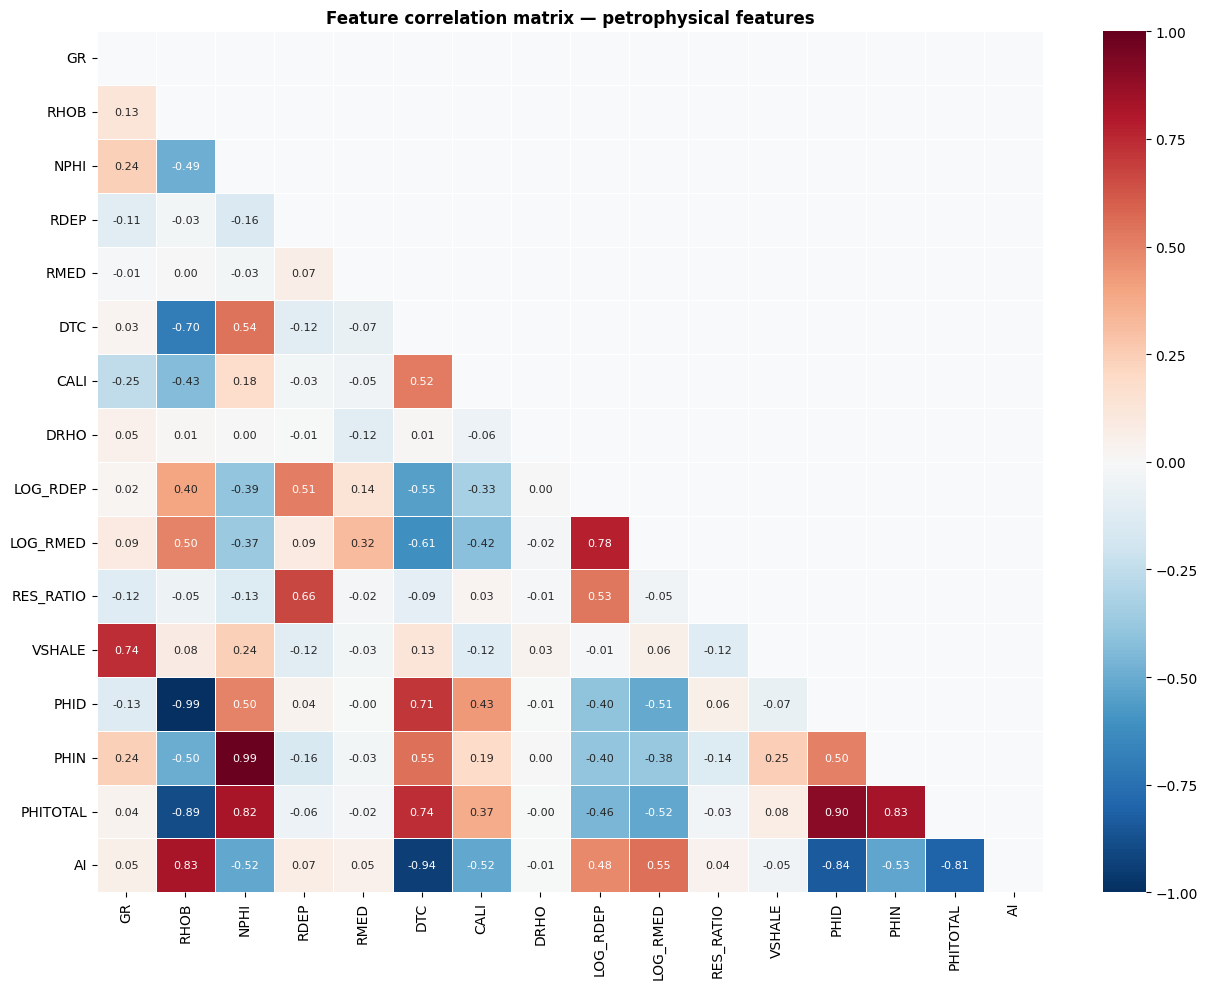

Saved fig08_feature_correlation.png


In [12]:
# Correlation heatmap of base features (not rolling)
base_only = [f for f in BASE_FEATURES
             if "ROLL" not in f and f not in ["DEPTH_ABS","DEPTH_NORM","X_LOC","Y_LOC","Z_LOC"]]

sample = labelled[base_only].sample(min(50000, len(labelled)), random_state=42)
corr = sample.corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={"size": 8}, linewidths=0.5)
ax.set_title("Feature correlation matrix — petrophysical features", fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig(FIGS / "fig08_feature_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig08_feature_correlation.png")


## 7. Feature distributions per lithofacies (derived features)

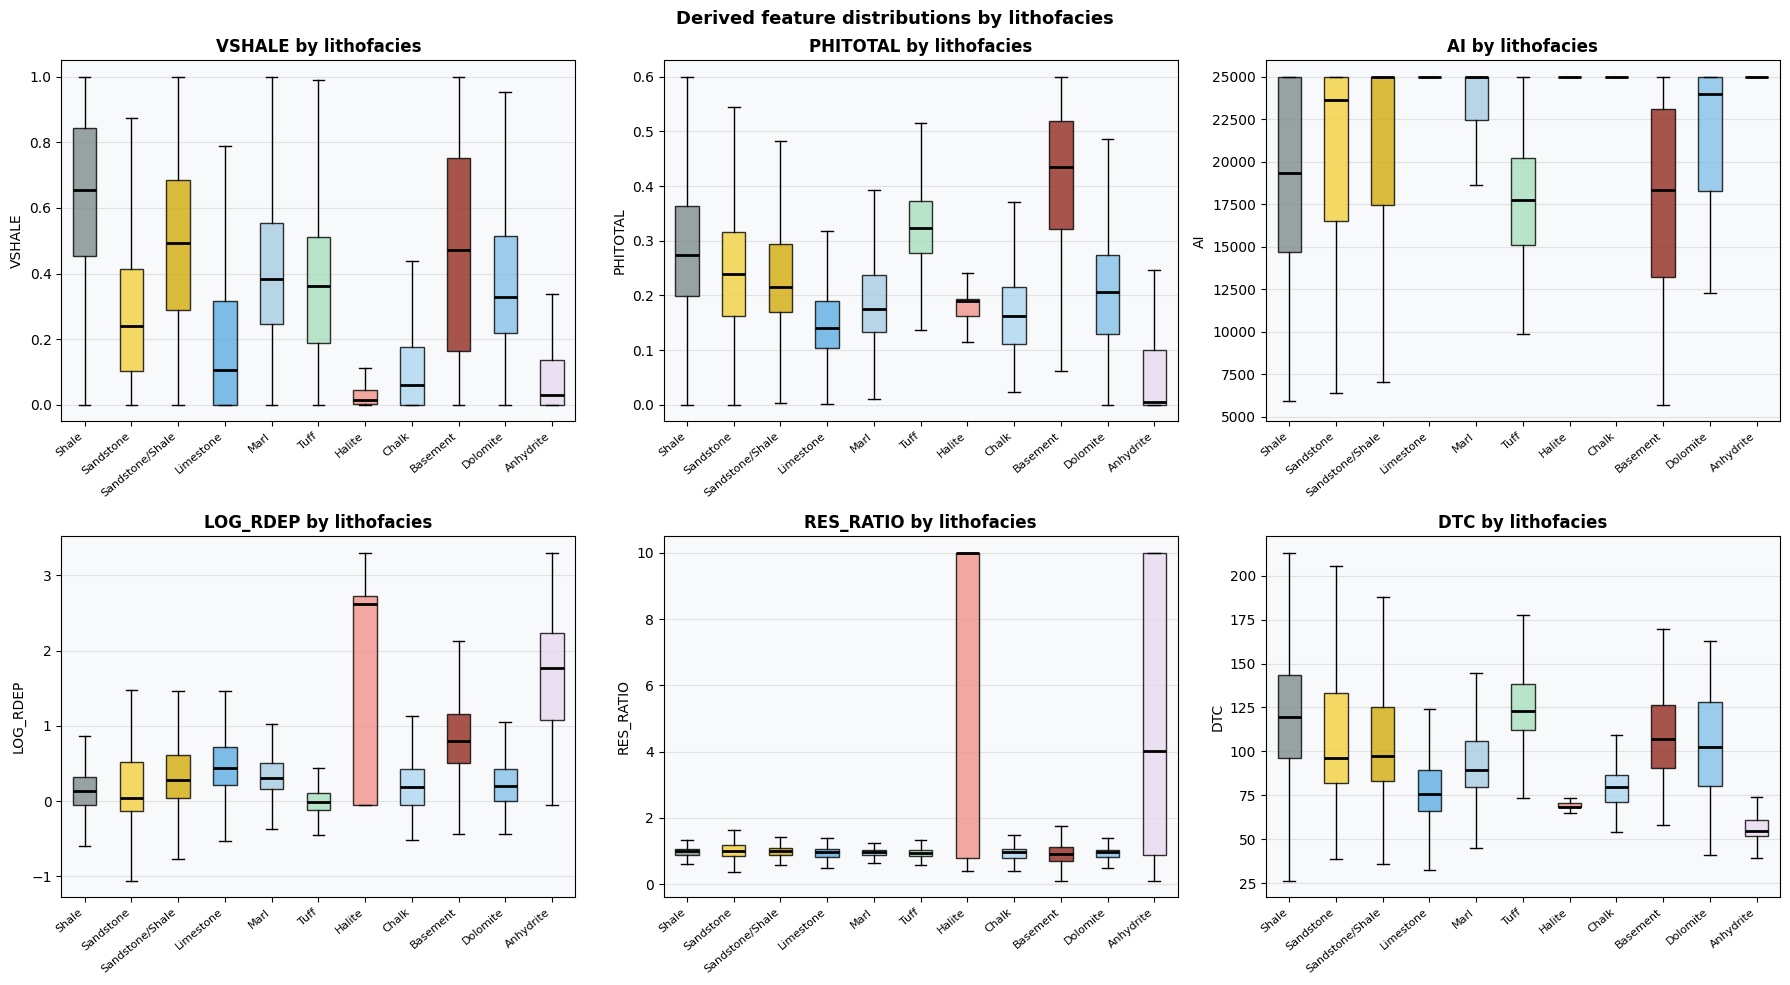

Saved fig09_derived_feature_distributions.png


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
derived = ["VSHALE", "PHITOTAL", "AI", "LOG_RDEP", "RES_RATIO", "DTC"]
lith_order = labelled["LITHOFACIES"].value_counts().index.tolist()

for ax, feat in zip(axes.flat, derived):
    data = [labelled[labelled["LITHOFACIES"] == l][feat].dropna().values
            for l in lith_order]
    bp = ax.boxplot(data, patch_artist=True, showfliers=False,
                    medianprops={"color": "black", "lw": 2})
    for patch, lith in zip(bp["boxes"], lith_order):
        patch.set_facecolor(LITH_COLORS.get(lith, "#888"))
        patch.set_alpha(0.8)
    ax.set_xticklabels(lith_order, rotation=40, ha="right", fontsize=8)
    ax.set_ylabel(feat, fontsize=10)
    ax.set_title(f"{feat} by lithofacies", fontweight="bold")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Derived feature distributions by lithofacies", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGS / "fig09_derived_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig09_derived_feature_distributions.png")


## 8. Save feature matrix to parquet

In [14]:
import json

# Save full labelled dataset with features + labels
save_cols = ["WELL", DEPTH_COL, "LITHOFACIES", TARGET_COL,
             "FORCE_2020_LITHOFACIES_CONFIDENCE"] + BASE_FEATURES

save_cols = [c for c in save_cols if c in labelled.columns]
out_df = labelled[save_cols].copy()

# Encode lithofacies as integer label for modelling
lith_classes = sorted(out_df["LITHOFACIES"].unique())
lith_to_int  = {l: i for i, l in enumerate(lith_classes)}
int_to_lith  = {i: l for l, i in lith_to_int.items()}
out_df["LABEL"] = out_df["LITHOFACIES"].map(lith_to_int)

# Save
parquet_path = PROC_DIR / "features_labelled.parquet"
out_df.to_parquet(parquet_path, index=False)
print(f"Saved: {parquet_path.name}  ({parquet_path.stat().st_size / 1e6:.1f} MB)")

# Save metadata
meta = {
    "features"     : BASE_FEATURES,
    "n_features"   : len(BASE_FEATURES),
    "n_samples"    : len(out_df),
    "n_wells"      : out_df["WELL"].nunique(),
    "n_classes"    : len(lith_classes),
    "lith_to_int"  : lith_to_int,
    "int_to_lith"  : int_to_lith,
    "class_counts" : out_df["LITHOFACIES"].value_counts().to_dict(),
}
meta_path = PROC_DIR / "feature_metadata.json"
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)
print(f"Saved: {meta_path.name}")
print(f"\nFeature matrix: {out_df[BASE_FEATURES].shape}")
print(f"Classes        : {lith_classes}")


Saved: features_labelled.parquet  (422.7 MB)
Saved: feature_metadata.json

Feature matrix: (1431242, 41)
Classes        : ['Anhydrite', 'Basement', 'Chalk', 'Dolomite', 'Halite', 'Limestone', 'Marl', 'Sandstone', 'Sandstone/Shale', 'Shale', 'Tuff']


## Summary

### Feature engineering decisions

**Imputation strategy** — per-well median imputation before global median fallback.
This respects that each well has its own logging environment and tool calibration.
Global imputation would mix signals from different formations and depth ranges.

**Vshale from GR** — linear GR index using per-well P5/P95 as clean/shale endpoints.
This is the standard industry approach (linear Larionov method). It normalises for
borehole conditions and tool vintage variation across 118 wells.

**Density porosity (PHID)** — computed assuming sandstone matrix (2.65 g/cc).
Conservative choice for a dataset dominated by clastics. A limestone matrix (2.71)
would be more appropriate for carbonate intervals but would overestimate clastic porosity.

**Acoustic impedance (AI = RHOB × Vp)** — one of the most diagnostic lithology
discriminators in the Norwegian Sea. Tight carbonates have AI > 10,000, clean sands
~6,000–8,000, shales ~5,000–7,000. The AI feature should significantly improve
limestone and dolomite classification.

**Rolling statistics** — 5-sample (~0.75m) and 21-sample (~3m) windows.
These encode the vertical context that petrophysicists read visually — coarsening
upward sequences, fining upward, abrupt bed boundaries. A point-based classifier
without context will miss these patterns.

**Log resistivity** — log10 transform normalises the 4-decade range of resistivity
values (0.1 to 1,000 ohm.m) into a roughly Gaussian distribution that tree-based
models and neural networks handle much better.

### Key findings from feature analysis
- AI cleanly separates carbonates (high) from clastics (low) and coal (very low)
- VSHALE provides cleaner shale separation than raw GR
- RES_RATIO > 2 is a strong hydrocarbon/tight rock indicator
- PHITOTAL separates porous sands from tight carbonates
- Rolling features capture bed thickness and transition patterns

### Output
- `data/processed/features_labelled.parquet` — full feature matrix
- `data/processed/feature_metadata.json` — feature names, class map, counts

